In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt

In [3]:
# Load the saved model, data
data_adv = pd.read_csv("data_adv.csv")
xgb_model = joblib.load("completion_prob_model_xgb.pkl")

In [5]:
# Feature List
cat_cols = ['route_group', 'route_of_targeted_receiver']

num_cols = [
    'flight_normalized_time', 'pass_length',
    'def_close1_dist', 'def_close2_dist', 'def_close3_dist', 'def_close4_dist',
    'tgt_rec_closing_speed_ball', 'def_close1_closing_speed_ball', 'def_close2_closing_speed_ball',
    'def_close3_closing_speed_ball', 'def_close4_closing_speed_ball', 'def_close1_closing_speed_ball_adv',
    'def_close2_closing_speed_ball_adv', 'def_close3_closing_speed_ball_adv', 'def_close4_closing_speed_ball_adv',
    'def_close1_momentum_adv', 'def_close2_momentum_adv', 'def_close3_momentum_adv', 'def_close4_momentum_adv',
    'def_close1_closing_speed_rec', 'def_close2_closing_speed_rec', 'def_close3_closing_speed_rec', 'def_close4_closing_speed_rec',
    'mean_separation_closest_3_defs', 'min_ball_dist_all_def', 'ball_dist_advantage',
    'def_close1_angle_rec_deg', 'def_close2_angle_rec_deg', 'def_close3_angle_rec_deg', 'def_close4_angle_rec_deg',
    'def_close1_angle_ball_deg', 'def_close2_angle_ball_deg', 'def_close3_angle_ball_deg', 'def_close4_angle_ball_deg',
    'tgt_rec_t_to_ball', 'min_t_def_to_ball', 'min_t_def_minus_t_rec', 'tgt_rec_ball_facing_angle',
    'tgt_rec_sideline_dist', 'tgt_rec_turn_angle_smoothed', 'crowdedness', 'tgt_rec_a_toward_ball',
    'closest_2_def_angle_diff'
]

model_cols = cat_cols + num_cols

In [16]:
def sample_play(df, completion = 0, route_type = None, route_group = None):
    possible_plays = df[df['complete'] == completion].copy()

    if route_type is not None:
        possible_plays = possible_plays[possible_plays['route_type'] == route_type]

    if route_group is not None:
        possible_plays = possible_plays[possible_plays['route_group'] == route_group]

    plays = possible_plays[['game_id', 'play_id']].drop_duplicates()

    if len(plays) == 0:
        print("ERROR: No plays exist...")
        return None, None  # no matching play

    # Randomly sample one play
    sampled_play = plays.sample(n=1, random_state=None).iloc[0]

    return sampled_play['game_id'], sampled_play['play_id']

In [13]:
def plot_predicted_catch_prob(df, game_id, play_id, model_cols, xgb_model):
    play_data = df[(df['game_id'] == game_id) &
                   (df['play_id'] == play_id) &
                   (df['to_release'] == 'after')
    ].copy()

    play_data = play_data.sort_values('frame_global', ascending = True)

    X_play = play_data[model_cols].copy()

    # Ensure categorical columns are encoded the same as training
    for col in ['route_group', 'route_of_targeted_receiver']:
        X_play[col] = X_play[col].astype('category').cat.codes

    # Predict completion probabilities
    play_data['completion_prob'] = xgb_model.predict_proba(X_play)[:, 1]

    # Plot probability over frames
    plt.figure(figsize=(10,5))
    plt.plot(play_data['frame_id'], play_data['completion_prob'], marker='o')
    plt.xlabel('Frame ID')
    plt.ylabel('Predicted Completion Probability')
    plt.title(f'Predicted Catch Probability Over Frames\nGame {game_id}, Play {play_id}')
    plt.grid(True)
    plt.show()

Game ID: 2023121710 Play ID: 4297


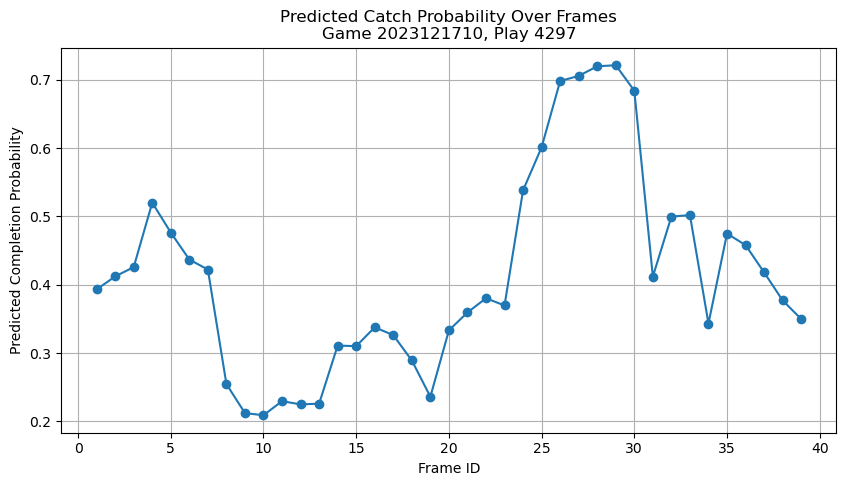

In [22]:
game_id, play_id = sample_play(data_adv, completion = 1, route_type = None, route_group = "INTERMEDIATE")
print(f"Game ID: {game_id} Play ID: {play_id}")

plot_predicted_catch_prob(data_adv, game_id, play_id, model_cols, xgb_model)